# Beer defensiveness — a quantitative teardown 🔬
### Bull vs bear beta · Newey-West CAPM alpha vs SPY · the recession-window paired *t* · the NBER look-ahead that kills the trade · a planted-asymmetric-beta positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Counter--cyclical%3F: Busted](https://img.shields.io/badge/Counter--cyclical%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "beer is recession-proof" on `TAP` (Molson Coors) and `SAM` (Boston Beer) vs `SPY`: (H₁) **downside defensiveness** — bear-beta < bull-beta < 1; (H₂) **recession outperformance** — positive recession-window excess with *t* > 2; (H₃) it is **investable** net of the NBER announcement lag and opportunity cost. We find **H₁ splits** (TAP yes, SAM no — and it's just low beta), **H₂ rejected** (no leg clears *t* = 2), **H₃ rejected** (look-ahead + a 3× wealth gap to SPY).

> ⚠️ **Not investment advice — data provenance.** `TAP`, `SAM`, `SPY` are month-end Adj Close via yfinance (as-of 2026-06-30; split+dividend adjusted). NBER recession windows are **hardcoded, cited** official dates (a labelled set of facts, not a feed). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from beer_recession import data, strategy as st

HAVE_PRICES = data.have_prices()
PX = data.load_prices() if HAVE_PRICES else None
print("price cache present:", HAVE_PRICES,
      "| NBER recessions in sample:", [r[0] for r in data.NBER_RECESSIONS])

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '1995 → 2026', 'n_spy': 377, 'n_sam': 367, 'tap_cagr': 7.32, 'tap_vol': 26.9, 'tap_sharpe': 0.4, 'tap_mdd': -66.4, 'sam_cagr': 6.52, 'sam_vol': 37.4, 'sam_sharpe': 0.36, 'sam_mdd': -85.4, 'spy_cagr': 11.12, 'spy_vol': 15.1, 'spy_sharpe': 0.78, 'spy_mdd': -50.8, 'tap_alpha': 3.25, 'tap_beta': 0.64, 'tap_t': 0.71, 'tap_p': 0.48, 'sam_alpha': 5.91, 'sam_beta': 0.68, 'sam_t': 0.84, 'sam_p': 0.403, 'tap_down_beta': 0.6, 'tap_up_beta': 0.7, 'tap_asym': -0.1, 'tap_def': 1, 'sam_down_beta': 0.87, 'sam_up_beta': 0.79, 'sam_asym': 0.09, 'sam_def': 0, 'n_down': 130, 'n_up': 247, 'rec_n': 31, 'tap_rec_mean': -1.44, 'tap_rec_excess': 0.25, 'tap_rec_t': 0.14, 'tap_rec_p': 0.891, 'tap_rec_cum': -48.1, 'sam_rec_mean': 2.42, 'sam_rec_excess': 4.12, 'sam_rec_t': 1.87, 'sam_rec_p': 0.071, 'sam_rec_cum': 64.3, 'spy_rec_mean': -1.7, 'spy_rec_cum': -45.6, 'rec_labels': ['2001 dot-com', '2008 GFC', '2020 COVID'], 'tap_by_rec': [-13.8, -19.3, -25.4], 'sam_by_rec': [40.8, -10.8, 30.9], 'spy_by_rec': [-7.1, -35.5, -9.2], 'tap_wealth': 9.19, 'sam_wealth': 6.91, 'spy_wealth': 27.45, 'hold_yrs': 31.4, 'nber_lag': 12, 'syn_down': 0.48, 'syn_up': 0.77, 'syn_plant_down': 0.5, 'syn_plant_up': 1.0}


price cache present: True | NBER recessions in sample: ['2001 dot-com', '2008 GFC', '2020 COVID']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No leg clears *t* ≥ 2. Recession-window excess: TAP *t* = **+0.14**, SAM *t* = **+1.87** (n=31 mo). CAPM α insignificant (TAP NW *t*=+0.71, SAM *t*=+0.84). |
| **Tradability** | `MIRAGE` | NBER dates a recession **~12 mo ex-post** (look-ahead); \$1 → **\$27** SPY vs **\$9** TAP / **\$7** SAM over 31y. |
| **Counter-cyclical?** | `BUSTED` | Only real effect = *low beta* (TAP β=0.64); but TAP fell **more** than SPY in 2/3 recessions, and SAM's down-beta (0.87) **exceeds** its up-beta (0.79). |

> 💡 In plain words: one beer stock is mildly low-beta, the other is anti-defensive on the downside, neither beats the index in recessions at any real significance, and the whole "hedge" would have cost you two-thirds of your money. "Counter-cyclical" gets confused with "low beta" — the former isn't here, the latter is cheaper elsewhere.

## 1 · The claim, steelmanned

Let a beer stock's monthly return be $r^P_t$ and the market's $r^M_t$ (SPY). The folklore is a joint hypothesis:

- **H₁ (downside defensiveness).** The bear-market beta is below the bull-market beta and below 1: $\;\beta^- < \beta^+ \;\wedge\; \beta^- < 1$, where $\beta^-$ is the OLS slope on $\{t: r^M_t < 0\}$ and $\beta^+$ on $\{t: r^M_t \ge 0\}$.
- **H₂ (recession outperformance).** Over NBER recession months $\mathcal{R}$, the mean excess $\;\bar{x} = \text{mean}_{t\in\mathcal{R}}(r^P_t - r^M_t)\;$ is positive with $t > 2$.
- **H₃ (investable).** After the ~12-month NBER announcement lag (you cannot condition on $\mathcal{R}$ in real time) and the full-sample opportunity cost, a beer-tilt beats simply holding SPY.

The steelman is that staple/'sin' consumption is income-inelastic, so a brewer's cash flows *should* be sticky through a downturn. The test is whether that shows up in the **stock**, **risk-adjusted**, **out-of-sample-tradable** — or only in the barstool.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, a beer stock would be a genuine equity hedge: it would cushion drawdowns (H₁), pay off precisely in recessions (H₂), and do so in a way you could actually implement (H₃). Each leg is separately falsifiable. H₁ is a **conditional-beta** statement — a risk characteristic, contemporaneous, no lag needed. H₂ is the **event-study** the folklore actually asserts, but on a tiny sample (three recessions, ~31 months) that is fragile to a single idiosyncratic name-quarter. H₃ is the **realisability** check: NBER recession dating is published with a long lag, so any recession-conditional strategy is a look-ahead unless you can forecast the turn — and a permanent beer tilt must be judged on its full-sample cost, not its best three windows. The claim needs all three; failing any downgrades it to a story about low beta.

## 3 · How we'd know — the protocol

- **Data.** `TAP`, `SAM`, `SPY` month-end Adj Close (yfinance, cached; splits + dividends folded in — *total-return-ish*, labelled as such). Sample 1995-01 → 2026-06 (SPY/TAP n=377 monthly returns; SAM from its 1995-11 listing, n=367).
- **Survivorship.** Named tickers, not a screen — but stated honestly: both firms *survived* the whole window, and SAM in particular is a craft-beer **winner**; the selection points *for* the defensiveness claim, so we treat any positive result with extra suspicion.
- **H₁ test.** Bull/bear conditional betas (split at $r^M=0$); defensive ⟺ $\beta^- < \beta^+ < 1$. No lag (a contemporaneous risk metric).
- **H₂ test.** Paired *t* of the recession-window monthly excess $r^P-r^M$ over the union of NBER recession months; the bar for `REAL` is $t \ge 2$ in the beer's favour. A per-recession breakdown checks the aggregate isn't one window.
- **CAPM α.** Newey-West (6-lag) HAC *t* of the full-sample alpha vs SPY — is there excess *after* market beta?
- **H₃ / cost (beat 6).** The NBER announcement lag (a look-ahead the folklore ignores) plus the full-sample terminal-wealth gap to SPY.
- **Positive control.** A deterministic stock with a *planted* asymmetric beta ($\beta^-{=}0.5 < \beta^+{=}1.0$); the engine must recover $\beta^- < \beta^+$ — proof a null on the real tape is a real null, not a broken detector.
- **What would make us say "defensive/counter-cyclical":** $\beta^-<\beta^+<1$ **on both names** *and* a recession-window *t* > 2. We find neither.

## 4 · The teardown

### 4a · H₁ — bull vs bear beta (is it defensive at all?)

Conditional OLS slope of each beer name on SPY, split by the sign of the market return. Defensive requires the down-beta *below* the up-beta and below 1.

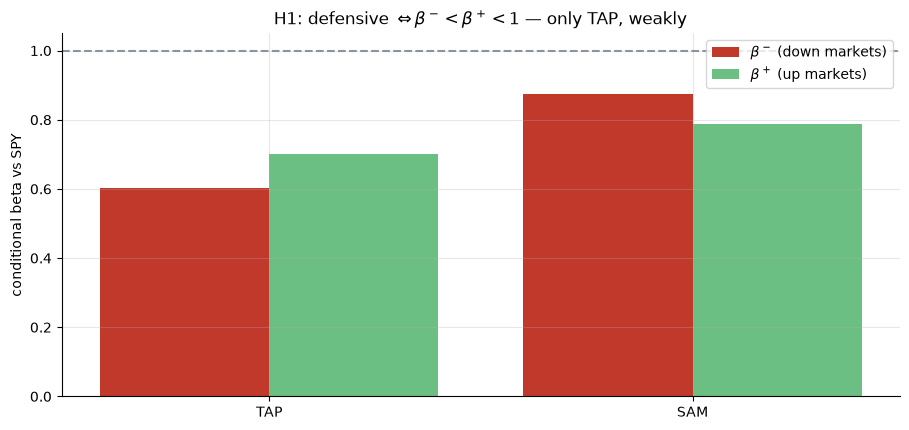

TAP: down-beta 0.60  up-beta 0.70  full 0.64  asymmetry -0.10  defensive=1
SAM: down-beta 0.87  up-beta 0.79  full 0.68  asymmetry +0.09  defensive=0


In [2]:
spy_r = PX['SPY'].pct_change().dropna() if HAVE_PRICES else None
rows = {}
for t in ['TAP','SAM']:
    if HAVE_PRICES:
        bb = st.bull_bear_beta(PX[t].pct_change().dropna(), spy_r, split=0.0)
        rows[t] = dict(d=bb['down_beta'], u=bb['up_beta'], f=bb['full_beta'], a=bb['asymmetry'], defn=bb['defensive'])
    else:
        pre='tap' if t=='TAP' else 'sam'
        rows[t] = dict(d=R[f'{pre}_down_beta'], u=R[f'{pre}_up_beta'], f=R[f'{pre}_beta'], a=R[f'{pre}_asym'], defn=R[f'{pre}_def'])
x=np.arange(2); fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, [rows['TAP']['d'],rows['SAM']['d']], .4, color=RED, label=r'$\beta^-$ (down markets)')
ax.bar(x+.2, [rows['TAP']['u'],rows['SAM']['u']], .4, color=GREEN, alpha=.7, label=r'$\beta^+$ (up markets)')
ax.axhline(1.0, ls='--', c=GREY); ax.set_xticks(x); ax.set_xticklabels(['TAP','SAM'])
ax.set_ylabel('conditional beta vs SPY'); ax.set_title(r'H1: defensive $\Leftrightarrow \beta^- < \beta^+ < 1$ — only TAP, weakly'); ax.legend()
plt.tight_layout(); plt.show()
for t in ['TAP','SAM']: r=rows[t]; print(f"{t}: down-beta {r['d']:.2f}  up-beta {r['u']:.2f}  full {r['f']:.2f}  asymmetry {r['a']:+.2f}  defensive={r['defn']}")

> 💡 In plain words: Molson Coors is a weak textbook defensive — $\beta^-$=**0.60** < $\beta^+$=**0.70**, both under 1 (a -0.10 asymmetry). Boston Beer is the **opposite**: $\beta^-$=**0.87** *exceeds* $\beta^+$=**0.79** (+0.09) — it participates *more* on the downside. H₁ holds for one name and fails for the other, and even for TAP it's a small gap on the same low-beta stock. This is "low beta," not a robust "beer is defensive" law.

### 4b · H₂ — recession-window returns (the direct counter-cyclical test)

Paired excess $r^P-r^M$ over the union of NBER recession months, and — crucially — the per-recession breakdown that shows whether any aggregate edge is broad or one window.

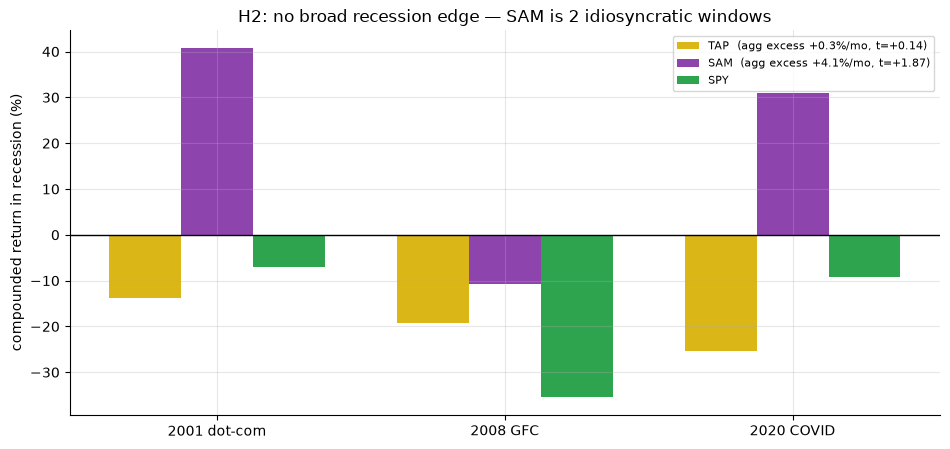

2001 dot-com    TAP  -13.8%  SAM  +40.8%  SPY   -7.1%
2008 GFC        TAP  -19.3%  SAM  -10.8%  SPY  -35.5%
2020 COVID      TAP  -25.4%  SAM  +30.9%  SPY   -9.2%
aggregate: TAP excess t=+0.14   SAM excess t=+1.87   (bar is |t|>=2)


In [3]:
labels=R['rec_labels']
if HAVE_PRICES:
    tre=st.recession_excess_t(PX['TAP'].pct_change().dropna(), spy_r, data.recession_mask)
    sre=st.recession_excess_t(PX['SAM'].pct_change().dropna(), spy_r, data.recession_mask)
    tb=st.recession_breakdown(PX['TAP'].pct_change().dropna(), spy_r, data.NBER_RECESSIONS)
    sb=st.recession_breakdown(PX['SAM'].pct_change().dropna(), spy_r, data.NBER_RECESSIONS)
    tapv=[tb[l]['stock']*100 for l in labels]; samv=[sb[l]['stock']*100 for l in labels]; spyv=[tb[l]['bench']*100 for l in labels]
    tt,st_t=tre['t'],sre['t']; tex,sex=tre['mean_excess']*100,sre['mean_excess']*100
else:
    tapv,samv,spyv=R['tap_by_rec'],R['sam_by_rec'],R['spy_by_rec']
    tt,st_t,tex,sex=R['tap_rec_t'],R['sam_rec_t'],R['tap_rec_excess'],R['sam_rec_excess']
x=np.arange(3); fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(x-.25, tapv, .25, color=AMBER, label=f'TAP  (agg excess {tex:+.1f}%/mo, t={tt:+.2f})')
ax.bar(x,      samv, .25, color='#8e44ad', label=f'SAM  (agg excess {sex:+.1f}%/mo, t={st_t:+.2f})')
ax.bar(x+.25, spyv, .25, color=GREEN, label='SPY')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('compounded return in recession (%)'); ax.set_title('H2: no broad recession edge — SAM is 2 idiosyncratic windows'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for i,l in enumerate(labels): print(f'{l:14s}  TAP {tapv[i]:+6.1f}%  SAM {samv[i]:+6.1f}%  SPY {spyv[i]:+6.1f}%')
print(f'aggregate: TAP excess t={tt:+.2f}   SAM excess t={st_t:+.2f}   (bar is |t|>=2)')

> 💡 In plain words: TAP's recession edge is a rounding error (*t* = +0.14); it fell **more** than SPY in 2001 (−13.8% vs −7.1%) and 2020 (−25.4% vs −9.2%), winning only the GFC. SAM's aggregate *t* = +1.87 looks tantalising but the breakdown indicts it: +40.8% (2001) and +30.9% (2020) are a small growth stock rallying, while in **2008 — the deepest, most beer-relevant recession — SAM *fell* 10.8%**. An 'edge' that reverses in the one recession that most tests the thesis is not a beer effect. H₂ rejected.

### 4c · CAPM α — is there excess after market beta?

Newey-West (6-lag) HAC regression of each name's monthly return on SPY. `REAL` needs $t_\alpha \ge 2$.

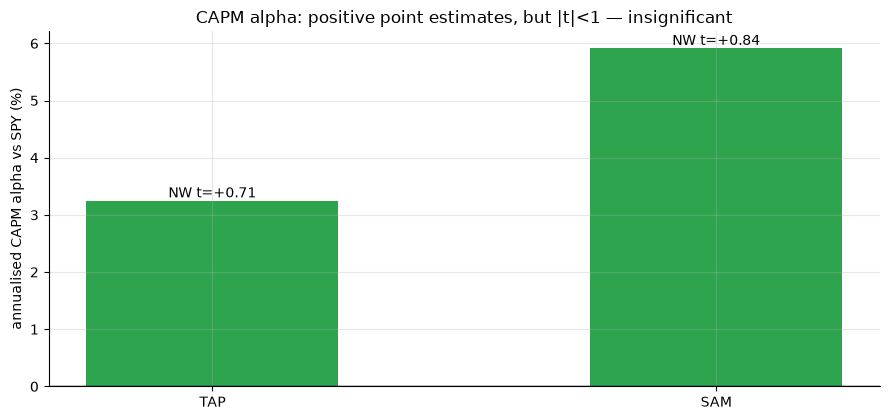

TAP: CAGR  7.32%  vol 26.9%  Sharpe 0.40  maxDD  -66.4%  |  alpha +3.25%/yr  beta 0.64  NW t +0.71
SAM: CAGR  6.52%  vol 37.4%  Sharpe 0.36  maxDD  -85.4%  |  alpha +5.91%/yr  beta 0.68  NW t +0.84


In [4]:
rows={}
for t in ['TAP','SAM']:
    if HAVE_PRICES:
        nw=st.newey_west_alpha_t(PX[t].pct_change().dropna(), spy_r, 6)
        s=st.summarize(PX[t])
        rows[t]=dict(alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'], cagr=s['cagr']*100, vol=s['vol']*100, sharpe=s['sharpe'], mdd=s['mdd']*100)
    else:
        pre='tap' if t=='TAP' else 'sam'
        rows[t]=dict(alpha=R[f'{pre}_alpha'], beta=R[f'{pre}_beta'], t=R[f'{pre}_t'], cagr=R[f'{pre}_cagr'], vol=R[f'{pre}_vol'], sharpe=R[f'{pre}_sharpe'], mdd=R[f'{pre}_mdd'])
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.0, 4.3)); cols=[GREEN if a>0 else RED for a in alphas]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised CAPM alpha vs SPY (%)')
for i,t in enumerate(labels): ax.annotate(f'NW t={ts[i]:+.2f}',(i,alphas[i]),ha='center',va='bottom')
ax.set_title('CAPM alpha: positive point estimates, but |t|<1 — insignificant')
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t}: CAGR {r['cagr']:5.2f}%  vol {r['vol']:4.1f}%  Sharpe {r['sharpe']:.2f}  maxDD {r['mdd']:6.1f}%  |  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: both point-estimate alphas are positive (TAP +3.2%/yr, SAM +5.9%/yr) but neither is distinguishable from zero (NW *t* = +0.71, +0.84) — and both names posted a *lower* CAGR (7.3%, 6.5%) than SPY (11.1%) with a *deeper* drawdown. Low beta bought a smoother ride in one name, not alpha, and not outperformance. The `NONE` stamp is earned.

### 4d · Positive control — the engine detects a planted defensive stock

A deterministic stock with a *planted* asymmetric beta ($\beta^-{=}0.5$, $\beta^+{=}1.0$, seed 728). The bull/bear engine must recover $\beta^- < \beta^+$ — proving the near-symmetry on the real tape is a true null, not a blind detector.

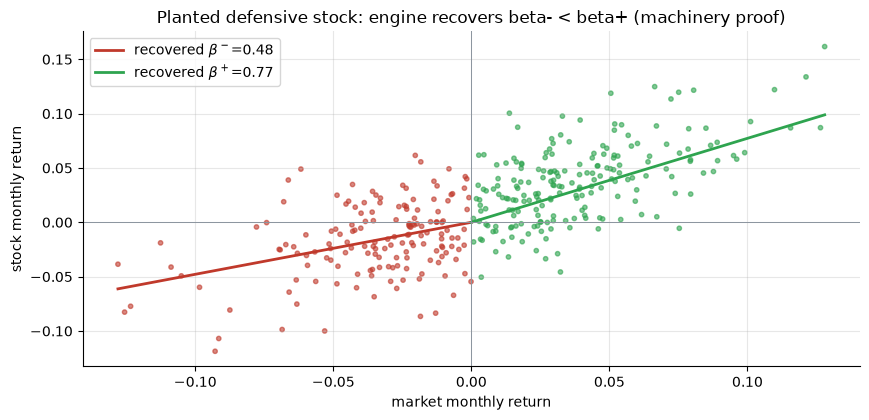

planted down/up 0.50/1.00 -> recovered down 0.48  up 0.77  recovered_defensive=1


In [5]:
mkt, stock = data.synthetic_defensive(beta_down=0.5, beta_up=1.0)
cr = st.control_recovers(stock, mkt, planted_down=0.5, planted_up=1.0)
down=mkt[mkt<0]; up=mkt[mkt>=0]
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.scatter(mkt, stock, s=10, c=np.where(mkt<0, RED, GREEN), alpha=.6)
xs=np.linspace(mkt.min(),0,20); ax.plot(xs, cr['down_beta']*xs, c=RED, lw=2, label=f"recovered $\\beta^-$={cr['down_beta']:.2f}")
xs2=np.linspace(0,mkt.max(),20); ax.plot(xs2, cr['up_beta']*xs2, c=GREEN, lw=2, label=f"recovered $\\beta^+$={cr['up_beta']:.2f}")
ax.axhline(0,c=GREY,lw=.7); ax.axvline(0,c=GREY,lw=.7)
ax.set_xlabel('market monthly return'); ax.set_ylabel('stock monthly return')
ax.set_title('Planted defensive stock: engine recovers beta- < beta+ (machinery proof)'); ax.legend()
plt.tight_layout(); plt.show()
print(f"planted down/up 0.50/1.00 -> recovered down {cr['down_beta']:.2f}  up {cr['up_beta']:.2f}  recovered_defensive={cr['recovered_defensive']}")

> 💡 In plain words: when a stock really *is* defensive, the engine sees it cleanly (recovered $\beta^-$≈**0.48** < $\beta^+$≈**0.77**). So the messy, name-dependent, insignificant result on the real beer tape is a genuine null — not a detector that can't tell defensive from cyclical. A synthetic control is a machinery proof, never market evidence.

## 5 · The verdict

- **Signal `NONE`** — no leg clears *t* ≥ 2 in the beer's favour: recession-window excess TAP *t*=+0.14, SAM *t*=+1.87 (n=31 months, and SAM's is two idiosyncratic windows); CAPM α insignificant (NW *t*=+0.71, +0.84). H₁ holds only for TAP and only weakly.
- **Tradability `MIRAGE`** — the NBER dates a recession ~12 months after it starts (a look-ahead), and holding beer "for defense" turned \$1 into \$9/\$7 vs SPY's \$27 over 31 years.
- **Counter-cyclical? `BUSTED`** — the only real effect is *low beta* (TAP β=0.64), which is not counter-cyclicality: TAP fell **more** than SPY in 2 of 3 recessions, and SAM's down-beta (0.87) exceeds its up-beta (0.79).

## 6 · Could you trade it? — the capacity & look-ahead reality

Two walls. **The look-ahead:** any recession-conditional beer tilt needs to know it's in a recession — but the NBER declared the 2008 recession in Dec-2008 (a year late) and dated the 2020 trough in Jul-2021 (15 months late). **The opportunity cost:** a *permanent* beer tilt is judged on the full sample, where it badly trails SPY.

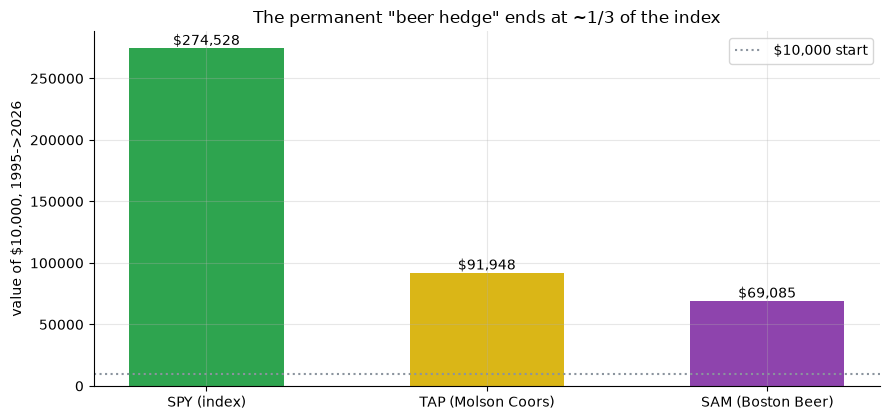

SPY: $274,528
TAP: $91,948
SAM: $69,085
NBER announcement lag ~12 months -> recession-conditional entry is a look-ahead


In [6]:
start=10_000.0
if HAVE_PRICES:
    mult=[st.terminal_wealth(PX[t]) for t in ['SPY','TAP','SAM']]
else:
    mult=[R['spy_wealth'],R['tap_wealth'],R['sam_wealth']]
ends=[start*m for m in mult]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(['SPY (index)','TAP (Molson Coors)','SAM (Boston Beer)'], ends, .55, color=[GREEN, AMBER, '#8e44ad'])
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.axhline(start, ls=':', c=GREY, label='$10,000 start'); ax.set_ylabel('value of $10,000, 1995->2026'); ax.legend()
ax.set_title('The permanent "beer hedge" ends at ~1/3 of the index')
plt.tight_layout(); plt.show()
for l,v in zip(['SPY','TAP','SAM'], ends): print(f'{l}: ${v:,.0f}')
print(f"NBER announcement lag ~{R['nber_lag']} months -> recession-conditional entry is a look-ahead")

> 💡 In plain words: there is no version of this that pays. The recession-timing version is un-implementable (you learn the recession's dates only after it's over); the buy-and-hold version compounds at a *discount* to the index it was supposed to protect you from. A defensive tilt is only worth it if the drawdown relief outweighs the return you surrender — here it emphatically does not, and for SAM the drawdown was actually *worse* (-85% vs SPY -51%).

## 7 · Going further

- **Broaden the universe.** Add `BUD`, `STZ`, `HEINY`, `DEO`, `MO`, `PM` and test whether a *basket* of brewers/sin-stocks shows a defensive tilt the single names don't — pooling across names is the honest way to beat the tiny-recession-sample problem.
- **Better recession conditioning.** Replace the ex-post NBER flag with a *real-time* recession probability (Sahm rule, yield-curve, claims) and re-run H₃ with an honest, no-look-ahead entry — the only way the recession-window question becomes tradable.
- **Volumes, the folklore's real claim.** Merge TTB/industry beer-shipment data: even if *volumes* are sticky, the mix shifts to cheaper brands (margin down), which is why the *stock* need not be defensive at all ([docs/references.md](../docs/references.md)).

*The reproducible core is offline and deterministic; prices are real (yfinance, total-return-ish), the NBER windows are **cited official dates**. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*